In [1]:
import numpy as np
import pandas as pd

from math import e

import matplotlib.pyplot as plt

np.random.seed(42)

print('라이브러리 import 완료')

라이브러리 import 완료


In [2]:
data = {
    'temperature': [10, 15, 20, 25, 30, 35],
    'humidity'   : [30, 40, 50, 60, 70, 80],
    'y'          : [0, 0, 1, 1, 0, 0]
}

df = pd.DataFrame(data)

df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,20,50,1
3,25,60,1
4,30,70,0
5,35,80,0


In [3]:
mask0 = df['y'] == 0
mask1 = df['y'] == 1

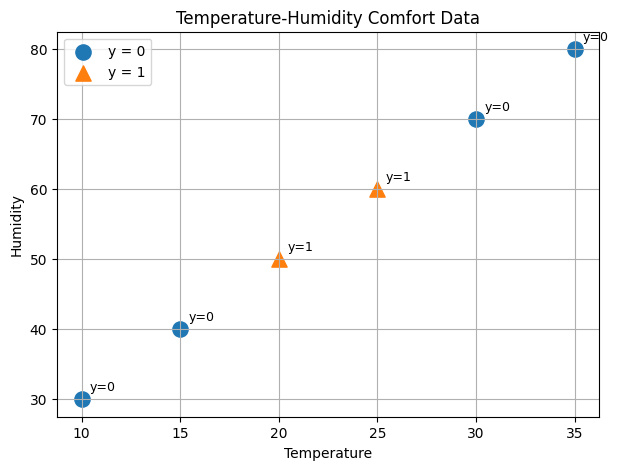

In [4]:
# 그림(figure) 하나를 만듭니다.
plt.figure(figsize=(7, 5))

# y=0인 점과 y=1인 점을 나누어 서로 다른 marker로 그립니다.
# boolean indexing: df["y"] == 0인 행만 골라냅니다.
mask0 = df['y'] == 0  # y가 0인 행(쾌적하지 않음)
mask1 = df['y'] == 1  # y가 1인 행(쾌적함)

# y=0 그룹: marker='o' (동그라미)
plt.scatter(df.loc[mask0, 'temperature'], df.loc[mask0, 'humidity'],
            marker='o', s=120, label='y = 0')

# y=1 그룹: marker='^' (삼각형)
plt.scatter(df.loc[mask1, 'temperature'], df.loc[mask1, 'humidity'],
            marker='^', s=120, label='y = 1')

# 각 점 옆에 y값을 작게 표시합니다.
# zip으로 (온도, 습도, y)를 한 줄씩 꺼내면서 텍스트를 붙입니다.
for temp, hum, yv in zip(df['temperature'], df['humidity'], df['y']):
    plt.annotate(f'y={yv}', (temp, hum),
                 textcoords='offset points', xytext=(6, 6), fontsize=9)
    
# 축 라벨, 제목, 범례, 격자 설정
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.title('Temperature-Humidity Comfort Data')
plt.legend()
plt.grid(True)

plt.show()

In [5]:
# X_raw: 원본 입력값. 온도와 습도를 나란히 붙여 (행의 수, 2) 모양으로 만듭니다.
#        shape = (n, 2) -> 열 0 = 온도, 열 1 = 습도
X_raw = df[['temperature', 'humidity']].to_numpy(dtype=float)    # to_numpy(): 줄 번호로 인한 계산 오류 방지

In [6]:
# y: 실제 정답. (n, 1) 모양의 세로 벡터로 만듭니다.
# n은 데이터 개수입니다. 이번 데이터는 6개이므로 y의 shape은 (6, 1)이 됩니다.
# 뒤에서 계산할 H_output, z_output도 shape가 (6, 1)이므로, y와 모양이 딱 맞아
# Cost 계산이 안전하게 됩니다. (모양이 안 맞으면 계산에서 에러가 나거나 값이 이상해집니다.)
y = df['y'].to_numpy(dtype=float).reshape(-1, 1) 

In [7]:
# X_mean: 각 입력 컬럼(온도, 습도)의 평균.
#         axis=0은 '열 방향으로 계산' = 컬럼별 평균 이라는 뜻입니다.
#         keepdims=True 로 (1, 2) 모양을 유지해 브로드캐스팅이 쉽게 되도록 합니다.
X_mean = X_raw.mean(axis=0, keepdims=True)    # shape = (1, 2)

# X_std: 각 입력 컬럼의 표준편차.
X_std = X_raw.std(axis=0, keepdims=True)      # shape = (1, 2)

print('X_mean (온도평균, 습도평균):', X_mean)
print('X_std  (온도표준편차, 습도표준편차):', X_std)

X_mean (온도평균, 습도평균): [[22.5 55. ]]
X_std  (온도표준편차, 습도표준편차): [[ 8.53912564 17.07825128]]


In [8]:
# X_norm: 정규화된 입력값. (원본 - 평균) / 표준편차
#          X_raw는 (n, 2), X_mean/X_std는 (1, 2)이지만
#          NumPy 브로드캐스팅 덕분에 컬럼별로 자동 계산됩니다.

# [정규화를 왜, 어디에 쓰는지 정리]
#   - 학습(Gradient Descent)에는 정규화된 값 X_norm을 사용합니다.
#     -> 온도(10~38)와 습도(30~80)처럼 범위가 다른 값을 그대로 넣으면 학습이 불안정하기 때문입니다.
#   - 반대로 그래프와 결과 해석에는 원래 온도, 습도 단위(X_raw)를 사용합니다.
#     -> 사람은 '온도 25도, 습도 55%'처럼 원래 단위가 훨씬 이해하기 쉽기 때문입니다.
#   즉, 컴퓨터 학습에는 정규화된 값이 안정적이고,
#       사람 해석에는 원래 단위가 편하므로, 둘을 목적에 맞게 나누어 씁니다.
X_norm = (X_raw - X_mean) / X_std             # shape = (n, 2)

In [9]:
print('X_raw shape:', X_raw.shape, '<- n=6이므로 (6, 2)')
print('y shape:', y.shape, '<- (6, 1)')
print('X_norm shape:', X_norm.shape, '<- n=6이므로 (6, 2)')

X_raw shape: (6, 2) <- n=6이므로 (6, 2)
y shape: (6, 1) <- (6, 1)
X_norm shape: (6, 2) <- n=6이므로 (6, 2)


In [10]:
# 정규화된 값을 DataFrame 에 새 컬럼으로 추가해 원본과 함께 봅니다.
df['temperature_norm'] = X_norm[:, 0]   # 정규화된 온도 
df['humidity_norm'] = X_norm[:, 1]      # 정규화된 습도

df

,temperature,humidity,y,temperature_norm,humidity_norm
0,10,30,0,-1.46385,-1.46385
1,15,40,0,-0.87831,-0.87831
2,20,50,1,-0.29277,-0.29277
3,25,60,1,0.29277,0.29277
4,30,70,0,0.87831,0.87831
5,35,80,0,1.46385,1.46385


In [11]:
def sigmoid(H):
    # H는 sigmoid 이전의 선형 출력값입니다. (확률이 아님)
    # H가 아주 크거나 아주 작으면 exp 계산에서 overflow(값이 너무 커짐)가 날 수 있습니다.
    # 그래서 H를 -500 ~ 500 사이로 잘라(clip) 계산을 안정적으로 만듭니다.
    H_clip = np.clip(H, -500, 500)
    
    # sigmoid 공식: 1 / (1 + e^(-H))
    # 반환값 z는 항상 0과 1 사이의 예측확률입니다.
    z = 1.0 / (1.0 + e ** (-H_clip))
    return z

# 동작을 확인합니다.
# H=0이면 z=0.5, H가 크면 z는 1에 가까워지고, H가 작으면 z는 0에 가까워집니다.
print('sigmoid(0)   =', sigmoid(np.array(0.0)))
print('sigmoid(10)  =', sigmoid(np.array(10.0)))
print('sigmoid(-10) =', sigmoid(np.array(-10.0)))

sigmoid(0)   = 0.5
sigmoid(10)  = 0.9999546021312976
sigmoid(-10) = 4.539786870243442e-05


In [12]:
def bce_cost(y, z):
    # y: 실제 정답(0 또는 1), z: 예측확률 (0~1)
    # MLP에서는 최종 예측확률 z_output을 이 함수의 z 자리에 넣어 Cost를 계산합니다.
    # epsilon: log(0)을 피하기 위한 아주 작은 값
    #   - log(0)은 무한대가 되어 Cost 계산이 불안정해집니다.
    #   - epsilon은 수학적 의미를 바꾸는 값이 아니라, 계산 안정성을 위한 값입니다.
    epsilon = 1e-7
    
    # z를 [epsilon, 1-epsilon] 범위로 잘라 log 계산을 안정적으로 만듭니다.
    z_clip = np.clip(z, epsilon, 1.0-epsilon)
    
    # BCE 공식: -[y*log(z) + (1-y)*log(1-z)]
    # 각 데이터마다 cost 값이 나오므로, 평균(mean)을 내어 하나의 cost로 만듭니다.
    cost = -(y * np.log(z_clip) + (1.0-y) * np.log(1.0-z_clip))
    
    # 반환값은 전체 데이터에 대한 '평균 Cost'입니다.
    return np.mean(cost)

In [13]:

# 동작 확인: 정답과 예측이 비슷하면 Cost가 작고, 반대면 큽니다.
y_test = np.array([[1.0], [0.0]])
z_good = np.array([[0.9], [0.1]])   # 잘 맞힌 예측
z_bad = np.array([[0.1], [0.9]])    # 크게 틀린 예측
print('잘 맞힌 경우의 Cost:', bce_cost(y_test, z_good))
print('크게 틀린 경우의 Cost:', bce_cost(y_test, z_bad))

잘 맞힌 경우의 Cost: 0.10536051565782628
크게 틀린 경우의 Cost: 2.302585092994046


In [14]:
# 학습에 사용될 입력을 교재 표기(X1, X2)에 맞게 준비합니다.
# 정규화된 온도/습도 열을 각각 (n, 1) 세로 벡터로 꺼냅니다.

#   - X_norm[:, [0]] 는 shape가 (n, 1) 인 세로 벡터입니다. (온도)
#   - X_norm[:, [1]] 는 shape가 (n, 1) 인 세로 벡터입니다. (습도)
# y도 (n, 1)이므로 계산할 때 모양이 딱 맞습니다.
X1_norm = X_norm[:, [0]]   # 정규화된 온도, shape = (n, 1)
X2_norm = X_norm[:, [1]]   # 정규화된 습도, shape = (n, 1)

In [15]:
# MLP 파라미터(가중치, 편향)를 교재 표기 그대로 '숫자 하나씩' 초기화합니다.
# np.random.randn()은 평균 0, 표준편차 1의 정규분포 난수를 하나 만듭니다.
# 여기에 0.1을 곱해 처음에는 '작은 값'에서 학습을 시작하도록 합니다.
#   - 왜 작은 값에서 시작하나요?
#     처음부터 가중치가 너무 크면 sigmoid 출력이 0 또는 1에 너무 가까이 붙어버려
#     학습이 잘 진행되지 않고 불안정해질 수 있기 때문입니다.

# --- 히든 뉴런 1 (H_hidden_1, z_hidden_1을 만드는 뉴런) --- 
a11 = np.random.randn() * 0.1  # X1(온도) -> 히든 뉴런 1 가중치
a12 = np.random.randn() * 0.1  # X1(습도) -> 히든 뉴런 1 가중치
b1 = 0.0                       # 히든 뉴런 1 편향 (0에서 시작해도 학습으로 업데이트됨)

# --- 히든 뉴런 2 (H_hidden_2, z_hidden_2을 만드는 뉴런) --- 
a21 = np.random.randn() * 0.1  # X1(온도) -> 히든 뉴런 2 가중치
a22 = np.random.randn() * 0.1  # X1(습도) -> 히든 뉴런 2 가중치
b2 = 0.0                       # 히든 뉴런 2 편향 

# --- 출력층 (H_output, z_output를 만드는 뉴런) ---
a31 = np.random.randn() * 0.1   # z_hidden_1 -> 출력층 가중치
a32 = np.random.randn() * 0.1   # z_hidden_2 -> 출력층 가중치
b3 = 0.0                        # 출력층 편향

In [16]:
# 초기 파라미터를 표(DataFrame)로 정리해 확인합니다.
param_table = pd.DataFrame({
    'name':    ['a11', 'a12', 'b1', 'a21', 'a22', 'b2', 'a31', 'a32', 'b3'],
    'value':   [round(v, 4) for v in [a11, a12, b1, a21, a22, b2, a31, a32, b3]],
    'meaning': [
        'X1(온도) -> 히든 뉴런 1 가중치',
        'X2(습도) -> 히든 뉴런 1 가중치',
        '히든 뉴런 1 편향',
        'X1(온도) -> 히든 뉴런 2 가중치',
        'X2(습도) -> 히든 뉴런 2 가중치',
        '히든 뉴런 2 편향',
        'z_hidden_1 -> 출력층 가중치',
        'z_hidden_2 -> 출력층 가중치',
        '출력층 편향',
    ],
})

param_table

,name,value,meaning
0,a11,0.0497,X1(온도) -> 히든 뉴런 1 가중치
1,a12,-0.0138,X2(습도) -> 히든 뉴런 1 가중치
2,b1,0.0000,히든 뉴런 1 편향
3,a21,0.0648,X1(온도) -> 히든 뉴런 2 가중치
4,a22,0.1523,X2(습도) -> 히든 뉴런 2 가중치
5,b2,0.0000,히든 뉴런 2 편향
6,a31,-0.0234,z_hidden_1 -> 출력층 가중치
7,a32,-0.0234,z_hidden_2 -> 출력층 가중치
8,b3,0.0000,출력층 편향


In [17]:
def mlp_forward_textbook_style(
    X1, X2, 
    a11, a12, b1,
    a21, a22, b2,
    a31, a32, b3
):
    # 이 함수는 '학습'을 하는 함수가 아니라, 현재 파라미터로 예측확률(z_output)을 계산하는 '순전파' 함수입니다.
    # 교재 순전파 흐름을 그대로 코드로 옮깁니다.
    # X1, X2는 원본 온도, 습도가 아니라, 각각 (n, 1) 세로 벡터로 만든 '정규화된' 온도, 습도입니다.
    
    # 인자 순서 요약:
    #   X1, X2       -> 정규화된 두 입력(온도, 습도)
    #   a11, a12, b1 -> 히든 뉴런 1의 파라미터
    #   a21, a22, b2 -> 히든 뉴런 2의 파라미터
    #   a31, a32, b3 -> 출력층의 파라미터
    # 반환값 요약:
    #   H_hidden_1, H_hidden_2, H_output -> sigmoid 이전의 선형 계산값 (확률 아님)
    #   z_hidden_1, z_hidden_2           -> 히든 뉴런의 sigmoid 출력값 (중간 출력값)
    #   z_output                         -> 최종 예측 확률
    
    # --- 히든 뉴런 1 ---
    H_hidden_1 = a11 * X1 + a12 * X2 + b1   # 히든 뉴런 1 선형 출력 (확률 아님)
    z_hidden_1 = sigmoid(H_hidden_1)        # 히든 뉴런 1 출력 (중간 출력값)
    
    # --- 히든 뉴런 2 ---
    H_hidden_2 = a21 * X1 + a22 * X2 + b2   # 히든 뉴런 2 선형 출력 (확률 아님)
    z_hidden_2 = sigmoid(H_hidden_2)        # 히든 뉴런 2 출력 (중간 출력값)
    
    # --- 출력층 ---
    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3   # 출력층 선형 출력 (확률 아님)
    z_output = sigmoid(H_output)                          # 최종 예측확률
    
    # 반환 순서는 교재 흐름(X1, X2 -> H_hidden_1, z_hidden_1 -> H_hidden_2, z_hidden_2 -> H_output, z_output)과 같게
    # 코드 결과를 교재 단계와 한 줄씩 비교하기 쉽도록 했습니다.
    return H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output

In [18]:
# 함수를 초기 파라미터로 한 번 실행해서 각 값의 shape을 확인합니다.
# 인자 순서는 함수 정의부와 같습니다:
#   X1_norm, X2_norm -> 히든 뉴런 1 -> 히든 뉴런 2 -> 출력층
H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output = mlp_forward_textbook_style(
    X1_norm, X2_norm,
    a11, a12, b1,    # = 히든 뉴런 1
    a21, a22, b2,    # = 히든 뉴런 2
    a31, a32, b3     # = 출력층
)

# shape 확인 표를 pandas DataFrame 으로 정리합니다.
forward_shape_table = pd.DataFrame({
    'name' :    ['H_hidden_1', 'z_hidden_1', 'H_hidden_2', 'z_hidden_2', 'H_output', 'z_output'],
    'shape':    [str(H_hidden_1.shape), str(z_hidden_1.shape), str(H_hidden_2.shape),
                 str(z_hidden_2.shape), str(H_output.shape), str(z_output.shape)],
    'meaning':  [
        '히든 뉴런 1 선형 출력',
        '히든 뉴런 1 출력(중간 출력값)',
        '히든 뉴런 2 선형 출력',
        '히든 뉴런 2 출력(중간 출력값)',
        '출력층 선형 출력',
        '최종 예측확률',
    ],
})

forward_shape_table

,name,shape,meaning
0,H_hidden_1,"(6, 1)",히든 뉴런 1 선형 출력
1,z_hidden_1,"(6, 1)",히든 뉴런 1 출력(중간 출력값)
2,H_hidden_2,"(6, 1)",히든 뉴런 2 선형 출력
3,z_hidden_2,"(6, 1)",히든 뉴런 2 출력(중간 출력값)
4,H_output,"(6, 1)",출력층 선형 출력
5,z_output,"(6, 1)",최종 예측확률


In [19]:
# ----- MLP 학습 (교재 표기: a11, a12, b1, a21, a22, b2, a31, a32, b3) -----
# 파라미터는 위 파라미터 초기화 셀에서 이미 초기화된 값을 그대로 이어서 사용합니다.

# 학습 설정 
learning_rate = 0.5    # 한 번에 얼마나 크게 이동할지 정하는 값입니다.
                       #   - 너무 크면 Cost가 불안정해질 수 있습니다. (다른 데이터에서는 더 작은 값이 필요할 수 있습니다.)
                       #   - 너무 작으면 학습이 너무 느려집니다.
epochs = 30000         # 전체 데이터를 몇 번 반복 학습할지

# trace_row_idx: 학습 도중 '관찰할 대표 데이터 1개'의 번호(행 위치)입니다.
#   - 학습 중 모든 데이터를 매번 출력하면 화면이 너무 길어집니다.
#   - 그래서 대표로 1개만 골라, 학습이 진행되면서 그 데이터의
#     MLP 내부 계산값(H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output)이 어떻게 바뀌는지 따라갑니다.
#   - 마치 한 학생의 답안이 학습 과정에서 어떻게 바뀌는지 계속 지켜보는 것과 같습니다.
trace_row_idx = 0

# 데이터 개수 n (gradient를 평균 낼 때 사용)
n = X1_norm.shape[0]   # n은 학습 데이터 개수입니다. 현재 데이터는 6개입니다.

In [20]:
# 학습 과정의 Cost를 저장할 리스트 (나중에 그래프로 그립니다.)
cost_history = []

for epoch in range(epochs):
    # ===== 순전파 (forward): X1, X2 -> H_hidden_1, H_hidden_2 -> z_hidden_1, z_hidden_2 -> H_output, z_output -> Cost =====
    H_hidden_1 = a11 * X1_norm + a12 * X2_norm + b1     # 히든 뉴런 1 선형 출력 (확률 아님)
    z_hidden_1 = sigmoid(H_hidden_1)                            # 히든 뉴런 1 출력 (중간 출력값)
    H_hidden_2 = a21 * X1_norm + a22 * X2_norm + b2     # 히든 뉴런 2 선형 출력 (확률 아님)
    z_hidden_2 = sigmoid(H_hidden_2)                            # 히든 뉴런 2 출력 (중간 출력값)
    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3                  # 출력층 선형 출력 (확률 아님)
    z_output = sigmoid(H_output)                                # 최종 예측확률
    cost = bce_cost(y, z_output)                        # Cost = BCE(y, z_output)
    cost_history.append(cost)
    
    # ===== gradient(기울기) 계산 [코드 구현용] =====
    # gradient 는 Cost를 줄이기 위해 각 파라미터를 어느 방향으로 움직일지 알려주는 값입니다.
    # 출력층에서 시작한 변화량을 히든층 쪽으로 거꾸로 전달합니다. (자세한 유도는 다음 강의)
    # [주의] 아래 gradient 공식이 '왜' 이렇게 나오는지는 다음 강의에서 자세히 유도합니다.
    #        여기서는 학습을 실행하기 위한 코드로만 사용합니다.
    # dH_output = z_output - y 는 출력층에서 시작하는 gradient 신호입니다.
    #   - 이 값은 '일반적인 오차'가 아니라, BCE Cost와 sigmoid 를 함께 미분했을 때 나오는 값입니다.
    dH_output = z_output - y                                # 출력층에서 시작하는 gradient 신호, shape (n, 1)
    grad_a31 = np.mean(dH_output * z_hidden_1)              # a31 을 얼마나 수정할지 (np.mean은 전체 데이터의 평균 gradient)
    grad_a32 = np.mean(dH_output * z_hidden_2)              # a32 을 얼마나 수정할지
    grad_b3 = np.mean(dH_output)                                # b3를 얼마나 수정할지
    
    # dH_hidden_1: 출력층의 gradient 신호(dH_output)가 히든 뉴런 1쪽으로 전달된 값입니다. (z_hidden_1 * (1-z_hidden_1)은 sigmoid 미분값)
    dH_hidden_1 = (dH_output * a31) * z_hidden_1 * (1 - z_hidden_1)         # 히든 뉴런 1쪽 gradient 신호 (sigmoid 미분 포함)
    grad_a11 = np.mean(dH_hidden_1 * X1_norm)            # a11 을 얼마나 수정할지
    grad_a12 = np.mean(dH_hidden_1 * X2_norm)            # a12 를 얼마나 수정할지
    grad_b1 = np.mean(dH_hidden_1)                       # b1  을 얼마나 수정할지
    
    # dH_hidden_2: 출력층의 gradient 신호(dH_outpu)가 히든 뉴런 2쪽으로 전달된 값입니다. (z_hidden_2 * (1-z_hidden_2)은 sigmoid 미분값)
    dH_hidden_2 = (dH_output * a32) * z_hidden_2 * (1 - z_hidden_2)         # 히든 뉴런 2쪽 gradient 신호 (sigmoid 미분 포함)
    grad_a21 = np.mean(dH_hidden_2 * X1_norm)            # a21 을 얼마나 수정할지
    grad_a22 = np.mean(dH_hidden_2 * X2_norm)            # a22 을 얼마나 수정할지
    grad_b2 = np.mean(dH_hidden_2)                       # b2 을 얼마나 수정할지
    
    # ===== 파라미터 업데이트: 새 값 = 기존 값 - learning_rate * gradient =====
    # (Cost를 줄이는 방향으로 9개 파라미터를 조금씩 수정합니다.)
    # gradient는 Cost가 '증가'하는 방향이므로, Cost를 줄이려면 그 반대 방향으로 이동하기 위해 뺍니다.
    # MLP는 수정할 파라미터가 9개라 코드가 길어질 뿐, 원리는 단일 퍼셉트론과 같습니다.
    # (순전파 -> Cost 계산 -> gradient 계산 -> 파라미터 업데이트)
    a31 = a31 - learning_rate * grad_a31
    a32 = a32 - learning_rate * grad_a32
    b3 = b3 - learning_rate * grad_b3
    a11 = a11 - learning_rate * grad_a11
    a12 = a12 - learning_rate * grad_a12
    b1 = b1 - learning_rate * grad_b1
    a21 = a21 - learning_rate * grad_a21
    a22 = a22 - learning_rate * grad_a22
    b2 = b2 - learning_rate * grad_b2
    
    # if epoch % 1000 == 0 or epoch == epochs - 1:
    #         print(f'epoch={epoch}, cost={cost_history[-1]:.6f}')
    #         print(f'  히든 뉴런 1: a11={a11:.4f}, a12={a12:.4f}, b1={b1:.4f}')
    #         print(f'  히든 뉴런 2: a21={a21:.4f}, a22={a22:.4f}, b2={b2:.4f}')
    #         print(f'  출력층     : a31={a31:.4f}, a32={a32:.4f}, b3={b3:.4f}')
    #         print('-' * 60)
    
    # ===== 대표 데이터 1개의 순전파 값 출력 =====
    #   - epoch < 5            : 학습 맨 처음(0,1,2,3,4)에는 값이 빠르게 변하므로 매번 출력합니다.
    #   - epoch > 0 and epoch % 3000 == 0 : 그 뒤에는 3000번마다 한 번씩만 출력합니다. (3000, 6000, 9000 ...)
    #     -> epoch > 0을 붙인 이유는, epoch 0은 이미 위의 epoch < 5에서 출력되므로
    #        중복해서 출력하지 않도록 하기 위해서입니다.
    if epoch < 5 or (epoch > 0 and epoch % 3000 == 0):
        # 대표 데이터 1개(trace_row_idx 번째)의 값만 꺼냅니다.
        # H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output는 모두 (n, 1) 모양이라, [trace_row_idx, 0]으로 그 행의 숫자 하나를 꺼냅니다.
        X1_t = X1_norm[trace_row_idx, 0]   # 이 데이터의 입력 X1 (정규화된 온도)
        X2_t = X2_norm[trace_row_idx, 0]   # 이 데이터의 입력 X2 (정규화된 습도)
        y_t = int(y[trace_row_idx, 0])     # 이 데이터의 실제 정답 (0 또는 1)
        
        # H_hidden_1, H_hidden_2 : Hidden Layer에서 sigmoid 를 적용하기 '전'의 선형 계산값입니다. (아직 확률이 아님)
        H_hidden_1_t = H_hidden_1[trace_row_idx, 0]
        H_hidden_2_t = H_hidden_2[trace_row_idx, 0]
        
        # z_hidden_1, z_hidden_2 : H_hidden_1, H_hidden_2에 sigmoid를 적용한 값. Hidden Layer의 '중간 결과'입니다. (항상 0~1)
        z_hidden_1_t = z_hidden_1[trace_row_idx, 0]
        z_hidden_2_t = z_hidden_2[trace_row_idx, 0]
        
        # H_output : Output Layer에서 sigmoid 이전의 선형 계산값입니다.
        #      중요) Output Layer는 원본 X1, X2가 아니라, Hidden Layer가 만든 z_hidden_1, z_hidden_2를 입력으로 받습니다.
        H_output_t = H_output[trace_row_idx, 0]
        
        # z_output : sigmoid(H_output)의 결과이자, 이 데이터의 최종 예측확률입니다. (항상 0~1)
        z_output_t = z_output[trace_row_idx, 0]
        
        # pred : z_output가 0.5 이상이면 1, 미만이면 0으로 정한 최종 예측 클래스입니다.
        pred_t = 1 if z_output_t >= 0.5 else 0
        
        print(f'[epoch {epoch}]')
        print(f'cost = {cost:.6f}')
        print()
        
        print(f'[대표 데이터] (X1, X2는 학습에 쓰는 정규화된 입력값입니다.)')
        print(f'X1 = {X1_t:.4f}  (원본 온도 = {X_raw[trace_row_idx, 0]:.1f})')
        print(f'X2 = {X2_t:.4f}  (원본 습도 = {X_raw[trace_row_idx, 1]:.1f})')
        print(f'y = {y_t}')
        print()
        
        print(f'[Hidden Layer]  (H = sigmoid 이전 선형 계산값, z = sigmoid 이후 중간 결과)')
        print(f'H_hidden_1 = {H_hidden_1_t:8.4f} -> z_hidden_1 = {z_hidden_1_t:.4f}')
        print(f'H_hidden_2 = {H_hidden_2_t:8.4f} -> z_hidden_2 = {z_hidden_2_t:.4f}')
        print()
        
        print(f'[Output Layer]  (원본 X1, X2가 아니라 z_hidden_1, z_hidden_2를 입력으로 받습니다.)')
        print(f'Output Layer 입력: z_hidden_1={z_hidden_1_t:.4f}, z_hidden_2={z_hidden_2_t:.4f}')
        print(f'H_output = {H_output_t:8.4f} -> z_output = {z_output_t:.4f}')
        print()
        
        print(f'[최종 예측]  (z_output가 0.5 이상이면 1, 미만이면 0)')
        print(f'z_output = {z_output_t:.4f} -> pred = {pred_t}')
        print('-' * 60)
        
        if epoch % 1000 == 0 or epoch == epochs - 1:
            print(f'epoch={epoch}, cost={cost_history[-1]:.6f}')
            print(f'  히든 뉴런 1: a11={a11:.4f}, a12={a12:.4f}, b1={b1:.4f}')
            print(f'  히든 뉴런 2: a21={a21:.4f}, a22={a22:.4f}, b2={b2:.4f}')
            print(f'  출력층     : a31={a31:.4f}, a32={a32:.4f}, b3={b3:.4f}')
            print('-' * 60)

[epoch 0]
cost = 0.689314

[대표 데이터] (X1, X2는 학습에 쓰는 정규화된 입력값입니다.)
X1 = -1.4639  (원본 온도 = 10.0)
X2 = -1.4639  (원본 습도 = 30.0)
y = 0

[Hidden Layer]  (H = sigmoid 이전 선형 계산값, z = sigmoid 이후 중간 결과)
H_hidden_1 =  -0.0525 -> z_hidden_1 = 0.4869
H_hidden_2 =  -0.3178 -> z_hidden_2 = 0.4212

[Output Layer]  (원본 X1, X2가 아니라 z_hidden_1, z_hidden_2를 입력으로 받습니다.)
Output Layer 입력: z_hidden_1=0.4869, z_hidden_2=0.4212
H_output =  -0.0213 -> z_output = 0.4947

[최종 예측]  (z_output가 0.5 이상이면 1, 미만이면 0)
z_output = 0.4947 -> pred = 0
------------------------------------------------------------
epoch=0, cost=0.689314
  히든 뉴런 1: a11=0.0497, a12=-0.0138, b1=0.0005
  히든 뉴런 2: a21=0.0648, a22=0.1523, b2=0.0005
  출력층     : a31=-0.0636, a32=-0.0636, b3=-0.0804
------------------------------------------------------------
[epoch 1]
cost = 0.671735

[대표 데이터] (X1, X2는 학습에 쓰는 정규화된 입력값입니다.)
X1 = -1.4639  (원본 온도 = 10.0)
X2 = -1.4639  (원본 습도 = 30.0)
y = 0

[Hidden Layer]  (H = sigmoid 이전 선형 계산값, z = sigmoid 이후 중간 결과)
H_hi

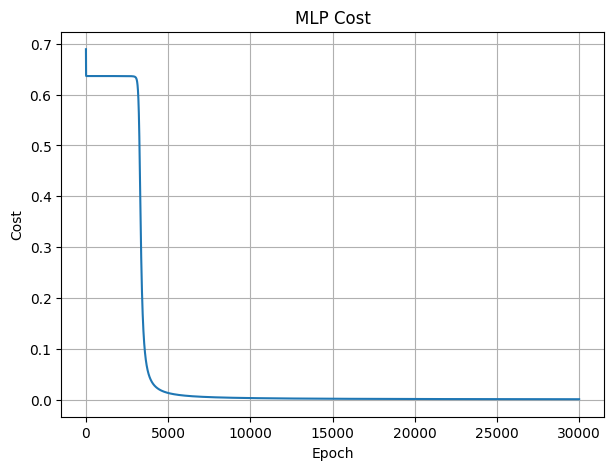

In [21]:
plt.figure(figsize=(7, 5))

# x축: epoch 번호, y축: 그때의 Cost
plt.plot(range(len(cost_history)), cost_history)

plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('MLP Cost')
plt.grid(True)

plt.show()

In [22]:
# 학습이 끝난 뒤, 학습된 9개 파라미터로 순전파를 '다시' 실행해 각 데이터의 최종 예측확률을 구합니다.
# (학습 루프 안의 값이 아니라, 최종 파라미터 기준의 결과를 표로 확인하기 위해서입니다.)
# 인자 순서는 함수 정의부와 같습니다: X1_norm, X2_norm -> 히든1 -> 히든2 -> 출력층(a31, a32, b3)
H_hidden_1_final, z_hidden_1_final, H_hidden_2_final, z_hidden_2_final, H_output_final, z_output_final = mlp_forward_textbook_style(
    X1_norm, X2_norm,
    a11, a12, b1,
    a21, a22, b2,
    a31, a32, b3
)

In [23]:
# 최종 예측확률 z_output가 0.5 이상이면 1, 아니면 0으로 판정합니다.
#   - (z_output_final >= 0.5)는 True/False를 만들고, .astype(int)가 이를 1/0으로 바꿉니다.
pred_mlp = (z_output_final >= 0.5).astype(int)

In [24]:
# (1) MLP 예측 결과 표: 원본 입력(온도, 습도), 실제 정답, 예측확률(z_output), 예측 클래스를 한 번에 비교하기 위한 표입니다.
result_df = pd.DataFrame({
    'temperature': df['temperature'].to_numpy(),
    'humidity': df['humidity'].to_numpy(),
    'y_actual': y.astype(int).ravel(),                     # 실제 정답
    'z_output_probability': np.round(z_output_final.ravel(), 4),       # 최종 예측확률 (소수 4자리)
    'mlp_pred': pred_mlp.ravel(),                          # 예측 클래스(0/1)
})

In [25]:
# is_correct: MLP 예측(mlp_pred)이 실제 정답(y_actual)과 같은지 확인하는 열입니다. (같으면 True)
result_df['is_correct'] = result_df['y_actual'] == result_df['mlp_pred']

# 전체 결과 표를 출력합니다.
result_df 

,temperature,humidity,y_actual,z_output_probability,mlp_pred,is_correct
0,10,30,0,0.0003,0,True
1,15,40,0,0.0006,0,True
2,20,50,1,0.9988,1,True
3,25,60,1,0.9988,1,True
4,30,70,0,0.0006,0,True
5,35,80,0,0.0003,0,True


In [26]:
# (2) 순전파 확인용 표: MLP 내부 계산값을 각 데이터마다 한 행씩 확인하기 위한 표입니다.
#     교재의 순전파 단계(H_hidden_1 -> z_hidden_1 -> H_hidden_2 -> z_hidden_2 -> H_output -> z_output)를 그대로 보여줍니다.
#     - H 계열(H_hidden_1, H_hidden_2, H_output)은 sigmoid 이전 값이라 음수, 0, 양수 모두 가능합니다. (확률이 아님)
#     - z 계열(z_hidden_1, z_hidden_2, z_output)은 sigmoid 이후 값이라 항상 0과 1 사이입니다.
#     - z_output 가 최종 예측확률이며, 위 결과 표의 z_output_probablity와 같은 값입니다.
forward_trace_df = pd.DataFrame({
    'temperature': df['temperature'].to_numpy(),
    'humidity': df['humidity'].to_numpy(),
    'y_actual': y.astype(int).ravel(),
    'H_hidden_1': np.round(H_hidden_1_final.ravel(), 4),   # 히든 뉴런 1 선형 출력 (확률 아님)
    'z_hidden_1': np.round(z_hidden_1_final.ravel(), 4),   # 히든 뉴런 1 출력 (중간 출력값)
    'H_hidden_2': np.round(H_hidden_2_final.ravel(), 4),   # 히든 뉴런 2 선형 출력 (확률 아님)
    'z_hidden_2': np.round(H_hidden_2_final.ravel(), 4),   # 히든 뉴런 2 출력 (중간 출력값)
    'H_output': np.round(H_output_final.ravel(), 4),       # 출력층 선형 출력 (확률 아님)
    'z_output': np.round(z_output_final.ravel(), 4)        # 최종 예측확률
})

forward_trace_df

,temperature,humidity,y_actual,H_hidden_1,z_hidden_1,H_hidden_2,z_hidden_2,H_output,z_output
0,10,30,0,9.5227,0.9999,-22.7221,-22.7221,-8.0353,0.0003
1,15,40,0,3.0984,0.9568,-16.2619,-16.2619,-7.3752,0.0006
2,20,50,1,-3.3260,0.0347,-9.8017,-9.8017,6.7470,0.9988
3,25,60,1,-9.7503,0.0001,-3.3415,-3.3415,6.7552,0.9988
4,30,70,0,-16.1746,0.0000,3.1187,3.1187,-7.3799,0.0006
5,35,80,0,-22.5989,0.0000,9.5788,9.5788,-8.0270,0.0003


In [28]:
# 시각화를 위한 온도, 습도 격자를 만듭니다. (여기서는 예측/그림 없이 격자만 준비)
# 기존 데이터 범위보다 약간 넓게 잡아 바깥쪽까지 보이도록 합니다.
temp_min = df['temperature'].min() - 2
temp_max = df['temperature'].max() + 2
hum_min = df['humidity'].min() - 2
hum_max = df['humidity'].max() + 2

# 온도 축과 습도 축을 각각 200개의 점으로 나눕니다.
# np.linspace는 최솟값부터 최댓값까지 일정한 간격의 숫자를 만듭니다.
temp_grid = np.linspace(temp_min, temp_max, 200)
hum_grid = np.linspace(hum_min, hum_max, 200)

# np.meshgrid는 온도축과 습도축을 조합해, 배경을 칠할 모든 좌표를 만듭니다.
# meshgrid로 (200, 200) 격자를 만듭니다. (TEMP=온도, HUM=습도)
TEMP, HUM = np.meshgrid(temp_grid, hum_grid)

print('TEMP shape:', TEMP.shape, '| HUM shape:', HUM.shape)

TEMP shape: (200, 200) | HUM shape: (200, 200)


In [29]:
# 격자 데이터도 학습 때와 '같은' 평균(X_mean)과 표준편차(X_std)로 정규화합니다.
# (새로 평균/표준편차를 계산하지 않고, 기존 값을 그대로 사용합니다.)
# X-mean, X_std는 shape(1, 2)이므로 [0, 0]=온도, [0, 1]=습도 입니다.
TEMP_norm = (TEMP - X_mean[0, 0]) / X_std[0, 0]   # 정규화된 온도 격자
HUM_norm = (HUM - X_mean[0, 1]) / X_std[0, 1]     # 정규화된 습도 격자

In [30]:
# 격자의 모든 점을 1차원으로 펼쳐 학습된 MLP에 넣습니다. 
# ravel()은 2차원 격자를 1차원으로 펼칩니다. (MLP 함수에 한 번에 넣기 위해서입니다.)
grid_X1 = TEMP_norm.ravel()    # 정규화된 온도 (펼친 1차원)
grid_X2 = HUM_norm.ravel()     # 정규화된 습도 (펼친 1차원)

# 학습이 끝난 파라미터로 순전파를 실행합니다. (반환값 중 최종 예측확률 z_output만 사용)
# _ 는 반환값 중 이번 셀에서 사용하지 않는 값을 받는 자리입니다.
_, _, _, _, _, grid_z_output = mlp_forward_textbook_style(
    grid_X1, grid_X2,
    a11, a12, b1,
    a21, a22, b2,
    a31, a32, b3
)

# z_output가 0.5 이상이면 1, 아니면 0으로 예측한 뒤, 다시 격자 모양으로 되돌립니다.
grid_pred = (grid_z_output >= 0.5).astype(int)
grid_pred_2d = grid_pred.reshape(TEMP.shape)

print('grid_pred_2d shape:', grid_pred_2d.shape)

grid_pred_2d shape: (200, 200)


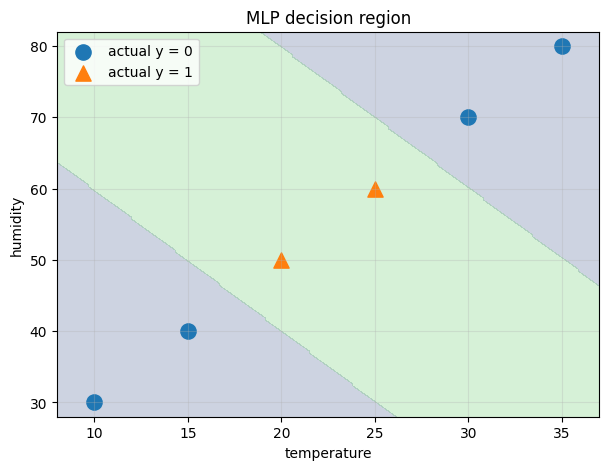

In [31]:
plt.figure(figsize=(7, 5))

# 배경: MLP가 0으로 예측한 영역과 1로 예측한 영역
# contourf는 격자 위의 예측값 0/1에 따라 배경 영역을 칠합니다.
# levels는 예측값 0과 1이 서로 다른 영역으로 보이도록 나누는 경계입니다.
# alpha=0.25는 배경색을 연하게 만들어 실제 데이터 점이 가려지지 않게 합니다.
plt.contourf(TEMP, HUM, grid_pred_2d, alpha=0.25, levels=[-0.5, 0.5, 1.5])

# 실제 데이터 점을 배경 위에 표시합니다.
# s=120은 점 크기를 키워 데이터 위치를 보기 쉽게 하고, label은 범례에 표시될 이름입니다.
mask0 = df['y'] == 0
mask1 = df['y'] == 1

plt.scatter(df.loc[mask0, 'temperature'], df.loc[mask0, 'humidity'],
            marker='o', s=120, label='actual y = 0')
plt.scatter(df.loc[mask1, 'temperature'], df.loc[mask1, 'humidity'],
            marker='^', s=120, label='actual y = 1')

plt.xlabel('temperature')
plt.ylabel('humidity')
plt.title('MLP decision region')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()